Environment: `velocity`

In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy
import decoupler
import scvelo
import IPython
import single_cell_analysis

In [2]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [3]:
# Read ChIP-seq targets
base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

In [4]:
# Load bulk differential expression results

bulk_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_combined.csv", index_col=0)
bulk_metadata = pandas.read_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv", index_col=0)
samples = bulk_metadata.index.to_list()
reprogramming_columns = bulk_de.columns[bulk_de.columns.str.contains("Reprogramming")]
reprogramming_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_reprogramming.csv", index_col=0)
mef_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mef.csv", index_col=0)
mesc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mesc.csv", index_col=0)
ipsc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_ipsc.csv", index_col=0)

In [5]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, bulk_de.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Dead end_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Dead end_corr", ascending=False).head(100).index.to_numpy()

In [6]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [7]:
differentially_expressed_genes = reprogramming_de.loc[variable_in_bulk].query("padj < 0.05").index.to_numpy()

In [8]:
# Find Hic2 target TFs that change significantly during reprogramming

# All target transcription factors
target_tfs = numpy.intersect1d(shared_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)
de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)

In [9]:
# Load CollecTRI database

collectri_df = decoupler.op.collectri(organism="mouse")

In [10]:
cell_markers = gseapy.get_library("PanglaoDB_Augmented_2021", organism="Mouse")
epithelial_markers = numpy.array(pandas.Series(cell_markers["Epithelial Cells"]).str.capitalize())
keratinocyte_markers = numpy.array(pandas.Series(cell_markers["Keratinocytes"]).str.capitalize())
stem_cell_markers = numpy.array(pandas.Series(cell_markers["Pluripotent Stem Cells"]).str.capitalize())
fibroblast_markers = numpy.array(pandas.Series(cell_markers["Fibroblasts"]).str.capitalize())
neuron_markers = numpy.array(pandas.Series(cell_markers["Neurons"]).str.capitalize())
kupffer_markers = numpy.array(pandas.Series(cell_markers["Kupffer Cells"]).str.capitalize())

2026-03-17 10:45:16 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-17 10:45:16 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.PanglaoDB_Augmented_2021.gmt, use local file


In [11]:
# Score cell types

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(epithelial_markers, adata.var_names),
    score_name="epithelial_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(keratinocyte_markers, adata.var_names),
    score_name="keratinocyte_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(stem_cell_markers, adata.var_names),
    score_name="stem_cell_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(fibroblast_markers, adata.var_names),
    score_name="fibroblast_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(neuron_markers, adata.var_names),
    score_name="neuron_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(kupffer_markers, adata.var_names),
    score_name="kupffer_score",
    use_raw=False
)

In [12]:
# Score apoptosis

go_database = gseapy.get_library("GO_Biological_Process_2025", organism="Mouse")
apoptosis_genes = numpy.array(pandas.Series(go_database["Positive Regulation of Apoptotic Process (GO:0043065)"]).str.capitalize())

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(apoptosis_genes, adata.var_names),
    score_name="apoptosis_score",
    use_raw=False
)

2026-03-17 10:45:17 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-17 10:45:17 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-03-17 10:45:17 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


# Diffusion map

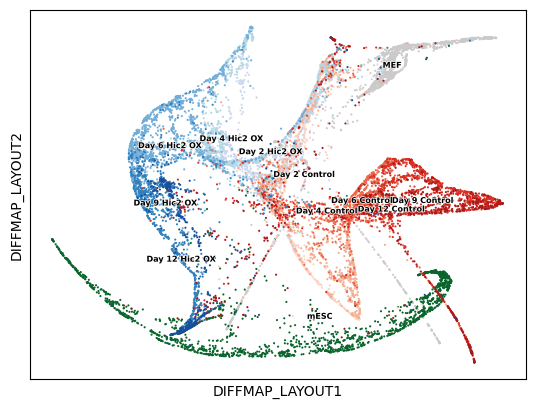

In [13]:
scanpy.tl.diffmap(adata)
scanpy.pp.neighbors(adata, n_neighbors=10, use_rep='X_diffmap', key_added="diffmap_neighbors")
scanpy.tl.draw_graph(adata, neighbors_key="diffmap_neighbors", key_added_ext="diffmap_layout", n_jobs=32)
scanpy.pl.draw_graph(adata, layout="diffmap_layout", legend_fontoutline = True, color=["sample"], 
                 legend_loc='on data', legend_fontsize=  'xx-small', title = "")

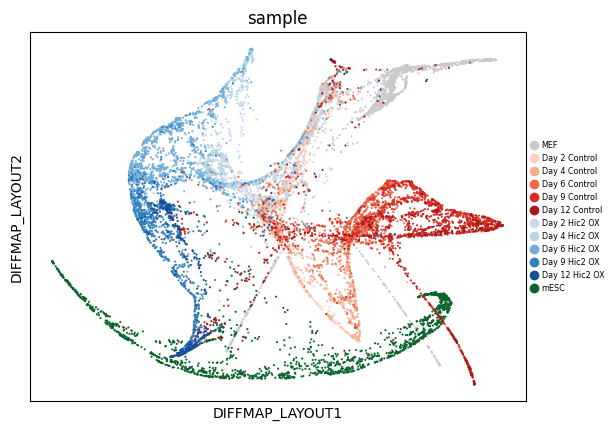

In [14]:
# Samples

scanpy.pl.draw_graph(adata, layout="diffmap_layout", legend_fontoutline = True, color=["sample"], 
                 legend_fontsize=  'xx-small', cmap="nipy_spectral_r", vmax="p99")

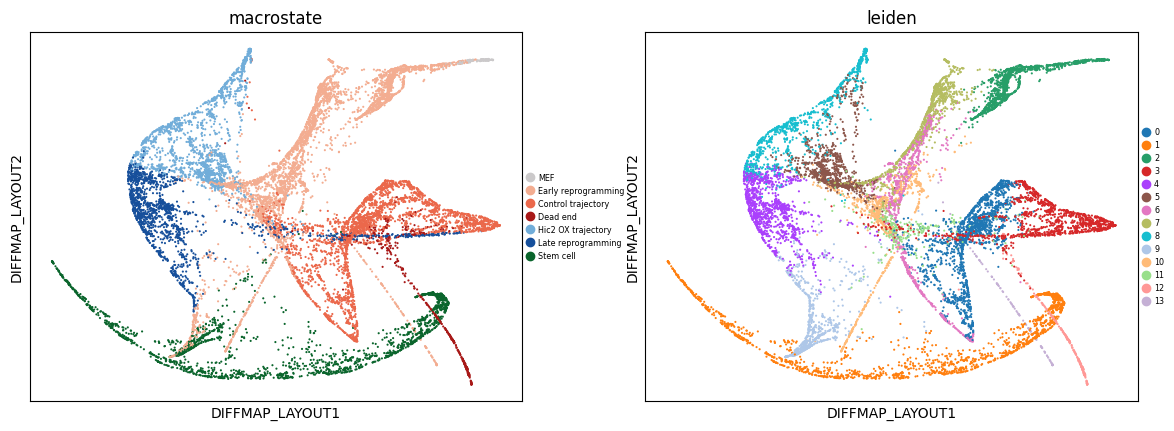

In [15]:
# Correlate with specific clusters

scanpy.pl.draw_graph(adata, layout="diffmap_layout", legend_fontoutline = True, color=["macrostate", "leiden"], 
                 legend_fontsize=  'xx-small', cmap="nipy_spectral_r", vmax="p99")

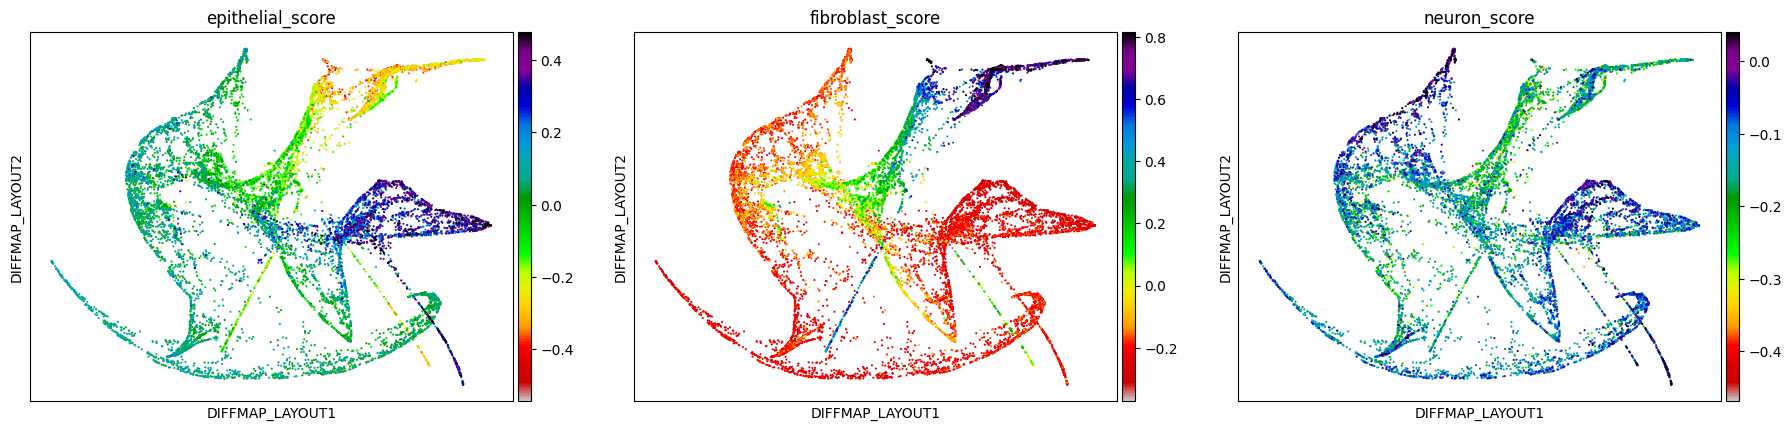

In [16]:
# Correlate with cell types

scanpy.pl.draw_graph(adata, layout="diffmap_layout", legend_fontoutline = True, color=["epithelial_score", "fibroblast_score", "neuron_score"], 
                 legend_fontsize=  'xx-small', cmap="nipy_spectral_r", vmax="p99")

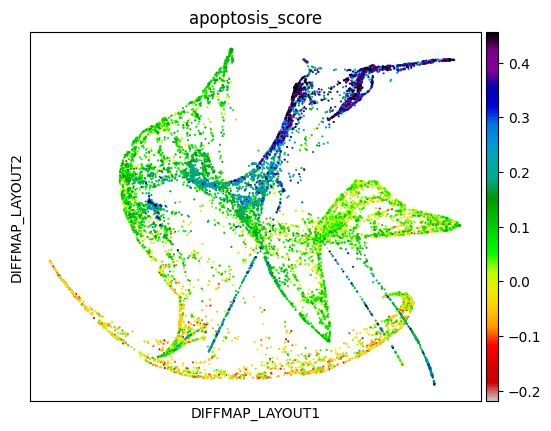

In [17]:
# Correlate with apoptosis

scanpy.pl.draw_graph(adata, layout="diffmap_layout", legend_fontoutline = True, color=["apoptosis_score"], 
                 legend_fontsize=  'xx-small', cmap="nipy_spectral_r", vmax="p99")

There seems to be 3 dead ends:

- Cluster 10: Fibroblast-like cells
- Cluster 12: The previously identified dead end
- Cluster 13: Almost exclusively MEFs

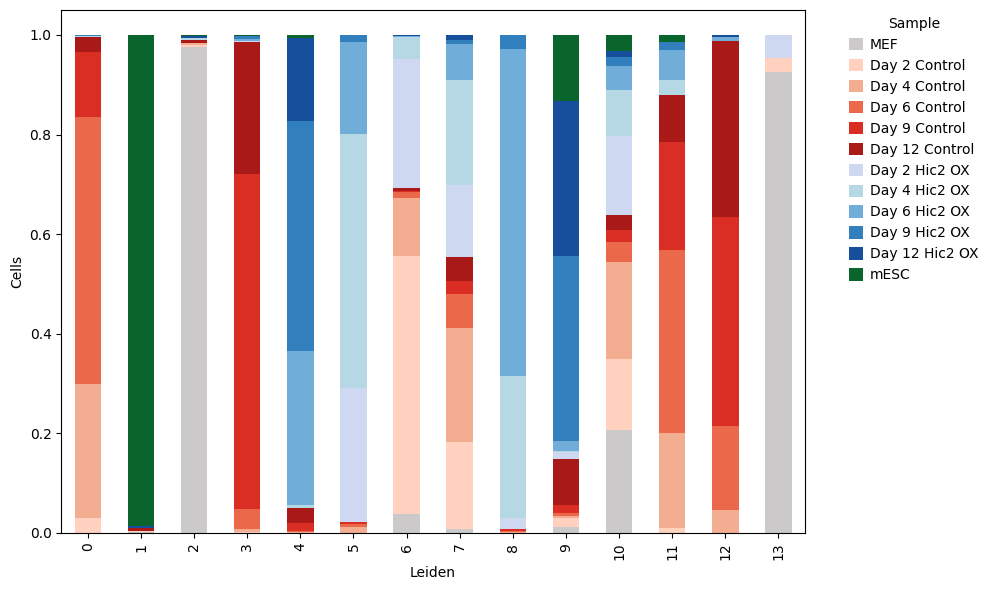

In [18]:
single_cell_analysis.plot_group_composition(adata, group_key="leiden", normalize=True)

## Studying the other dead ends, clusters 10 and 13

In [19]:
# Differential expression between clusters

scanpy.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="macrostate_rank_genes",
    use_raw=False
)

rank_dfs = {}

# extract the results into a dataframe for a specific target macrostate
for cluster in adata.obs["leiden"].cat.categories:
    rank_df = scanpy.get.rank_genes_groups_df(
        adata,
        key="macrostate_rank_genes",
        group=cluster
    )
    rank_df.index = rank_df["names"]
    rank_df = rank_df.drop(columns="names")
    rank_dfs[cluster] = rank_df

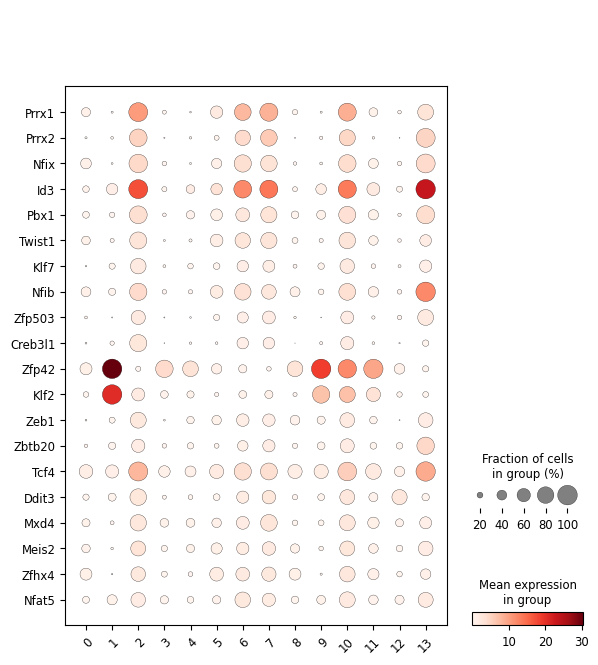

In [20]:
# Upregulated TFs

top_tfs = rank_dfs["10"].loc[numpy.intersect1d(tf_array, adata.var_names)].sort_values("scores", ascending=False).head(20)
axis = scanpy.pl.dotplot(adata, top_tfs.index, "leiden", swap_axes=True, show=False)["mainplot_ax"]
axis.set_xticklabels(axis.get_xticklabels(), rotation=45, rotation_mode="anchor", ha="right")
figure = pyplot.gcf()
pyplot.show()

2026-03-17 10:47:20,646 [WARNING] Duplicated values found in preranked stats: 1.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:47:23,084 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:47:25,548 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:47:27,948 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:47:30,365 [WARNING] Duplicated values found in preranked stats: 1.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:47:32,772 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be

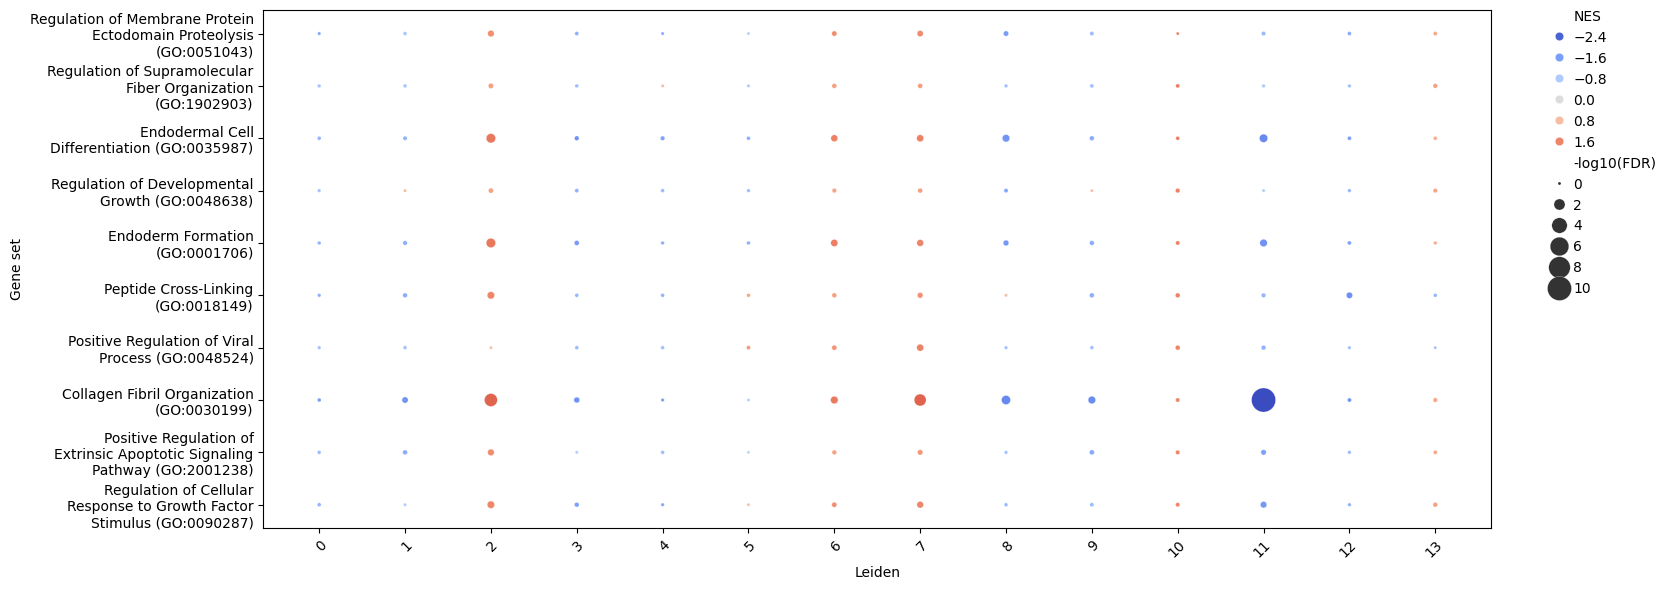

In [21]:
# GO terms

single_cell_analysis.compare_gsea(adata, gene_set="GO_Biological_Process_2025", group_key="leiden", top_from="10", significance_cutoff=1, enrichment_cutoff=-numpy.inf,
                                  n_top_terms=10)

2026-03-17 10:48:01 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-17 10:48:01 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/avesta/m26_losu/hic2_masters_project/single_cell_analysis.py:384: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticklabels(), rotation=45, rotation_mode="anchor", ha="right")


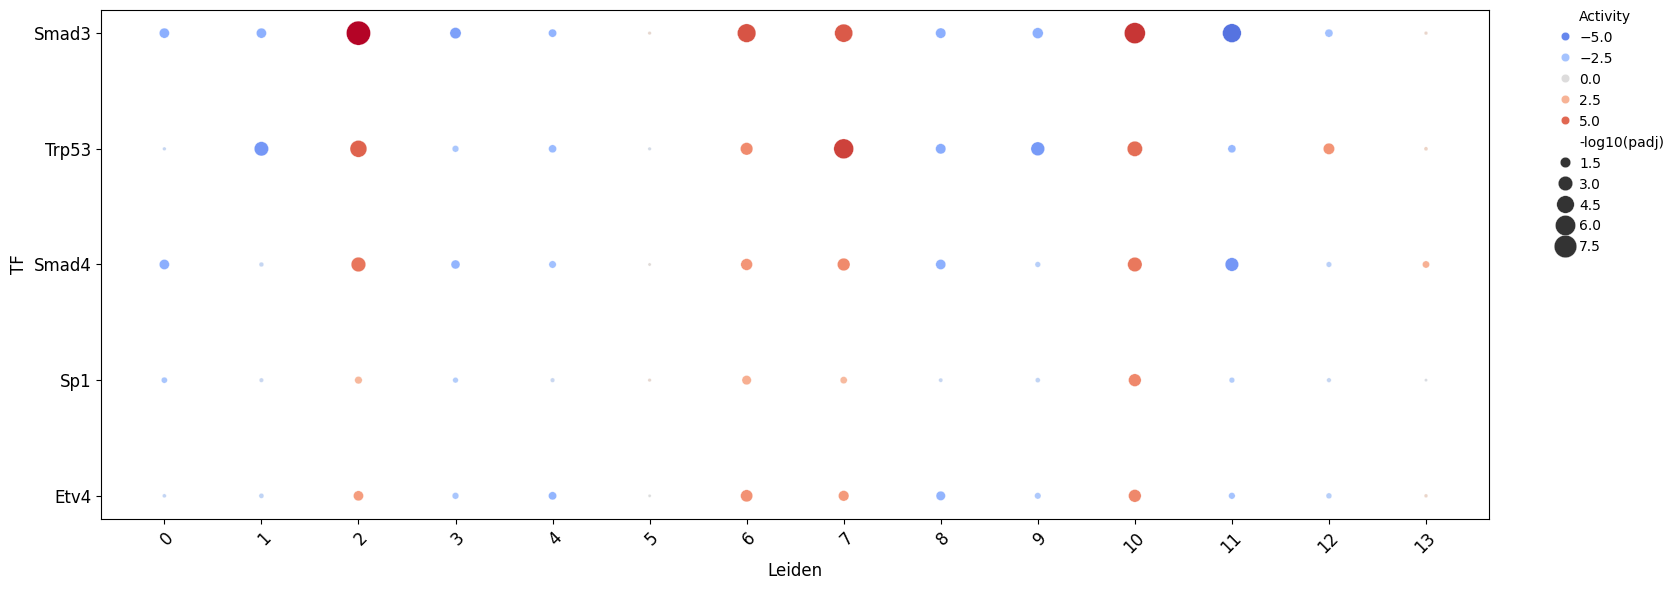

In [22]:
# TFs with higher activity

collectri_df = decoupler.op.collectri(organism="mouse")
single_cell_analysis.plot_tf_activity(adata, collectri_df, group_key="leiden", top_from="10", significance_cutoff=0.1)

Seems very similar to ordinary fibroblasts in cluster 2, probably because not all of the cells are at the edge

2026-03-17 10:48:04,511 [WARNING] Duplicated values found in preranked stats: 1.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:04,857 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:05,209 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:05,563 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:05,918 [WARNING] Duplicated values found in preranked stats: 1.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:06,276 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be

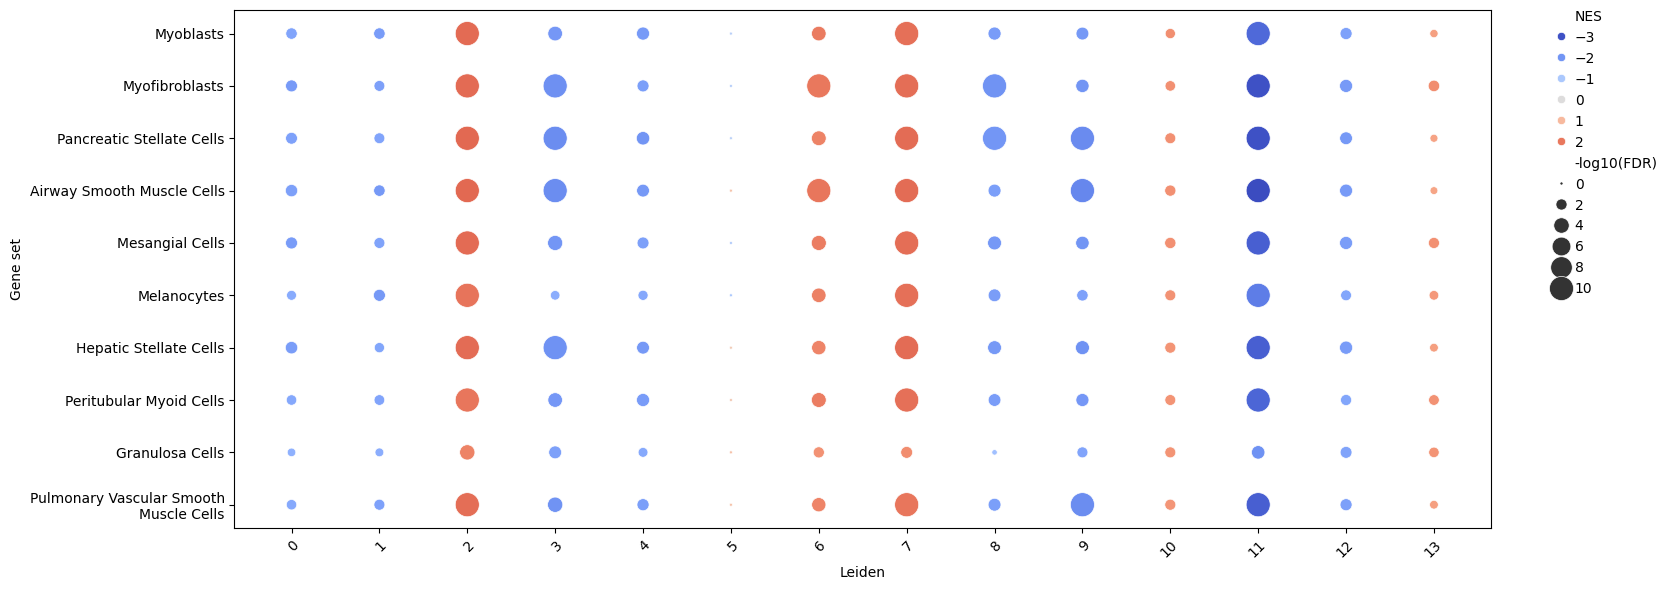

In [23]:
# Cell types in 10

single_cell_analysis.compare_gsea(adata, gene_set="PanglaoDB_Augmented_2021", group_key="leiden", top_from="10", significance_cutoff=0.5,
                                  n_top_terms=10)

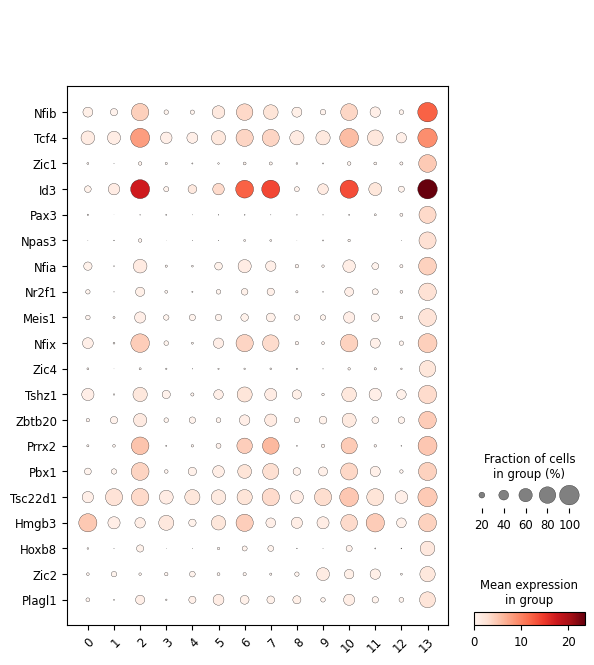

In [24]:
# Upregulated TFs in cluster 13

top_tfs = rank_dfs["13"].loc[numpy.intersect1d(tf_array, adata.var_names)].sort_values("scores", ascending=False).head(20)
axis = scanpy.pl.dotplot(adata, top_tfs.index, "leiden", swap_axes=True, show=False)["mainplot_ax"]
axis.set_xticklabels(axis.get_xticklabels(), rotation=45, rotation_mode="anchor", ha="right")
figure = pyplot.gcf()
pyplot.show()

2026-03-17 10:48:16 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-17 10:48:16 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/avesta/m26_losu/hic2_masters_project/single_cell_analysis.py:384: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticklabels(), rotation=45, rotation_mode="anchor", ha="right")


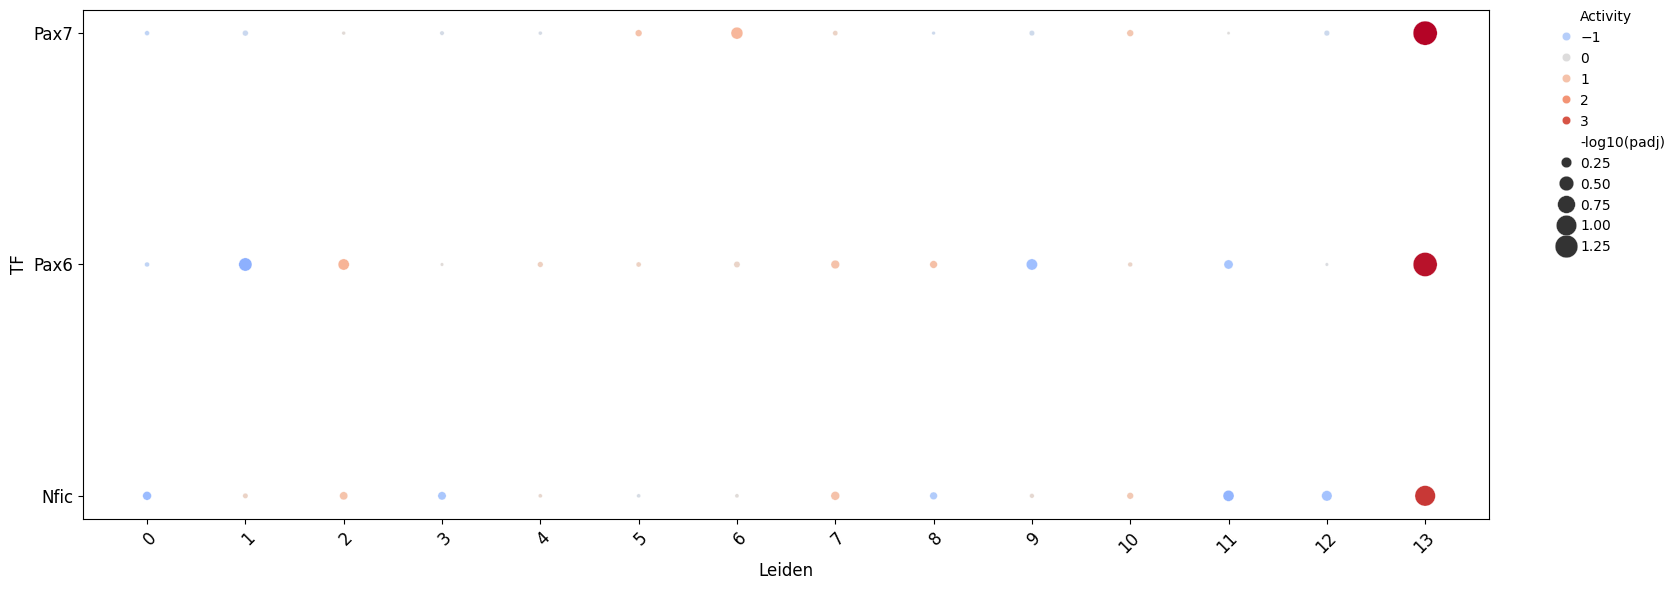

In [25]:
# TFs with higher activity in 13

collectri_df = decoupler.op.collectri(organism="mouse")
single_cell_analysis.plot_tf_activity(adata, collectri_df, group_key="leiden", top_from="13", significance_cutoff=0.1, activity_cutoff=0)

2026-03-17 10:48:19,108 [WARNING] Duplicated values found in preranked stats: 1.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:21,477 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:23,932 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:26,602 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:29,037 [WARNING] Duplicated values found in preranked stats: 1.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:31,468 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be

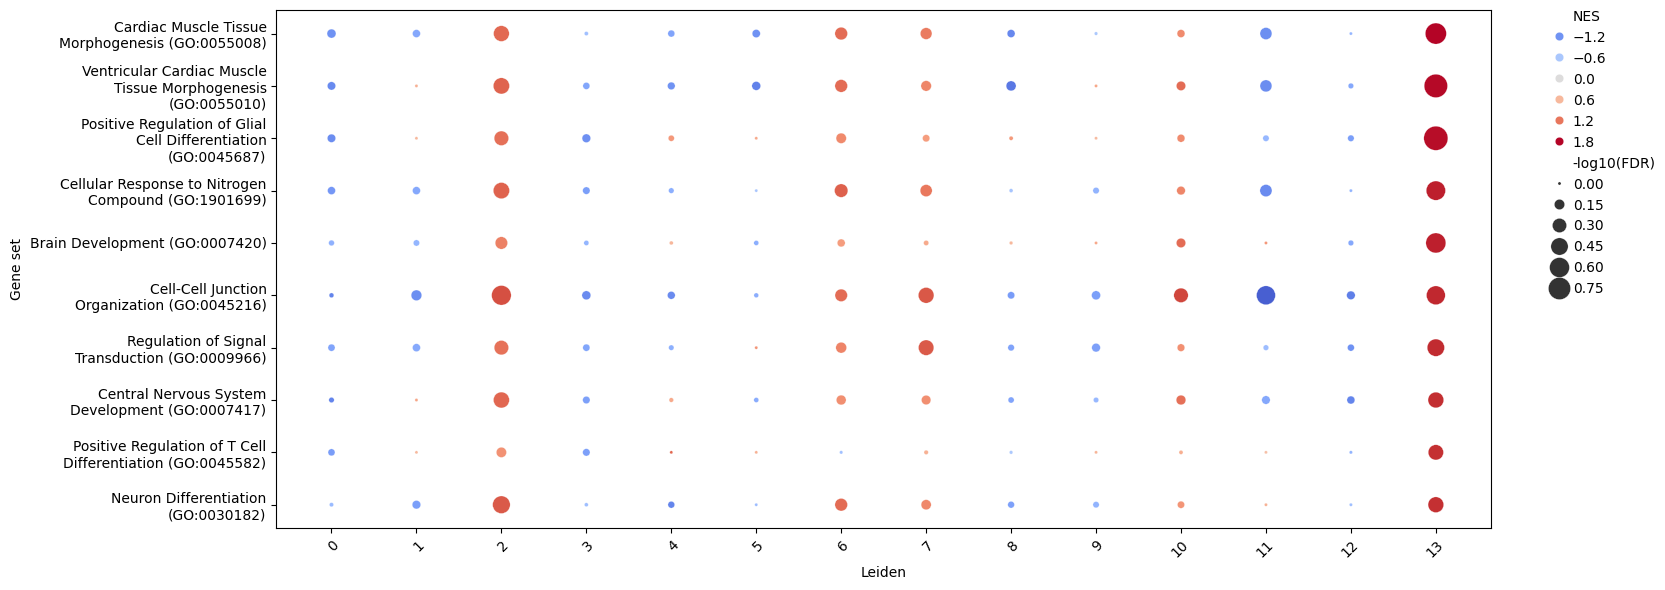

In [26]:
# GO terms

single_cell_analysis.compare_gsea(adata, gene_set="GO_Biological_Process_2025", group_key="leiden", top_from="13", significance_cutoff=0.5,
                                  n_top_terms=10)

2026-03-17 10:48:56,378 [WARNING] Duplicated values found in preranked stats: 1.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:56,727 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:57,087 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:57,475 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:57,863 [WARNING] Duplicated values found in preranked stats: 1.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-17 10:48:58,243 [WARNING] Duplicated values found in preranked stats: 1.20% of genes
The order of those genes will be

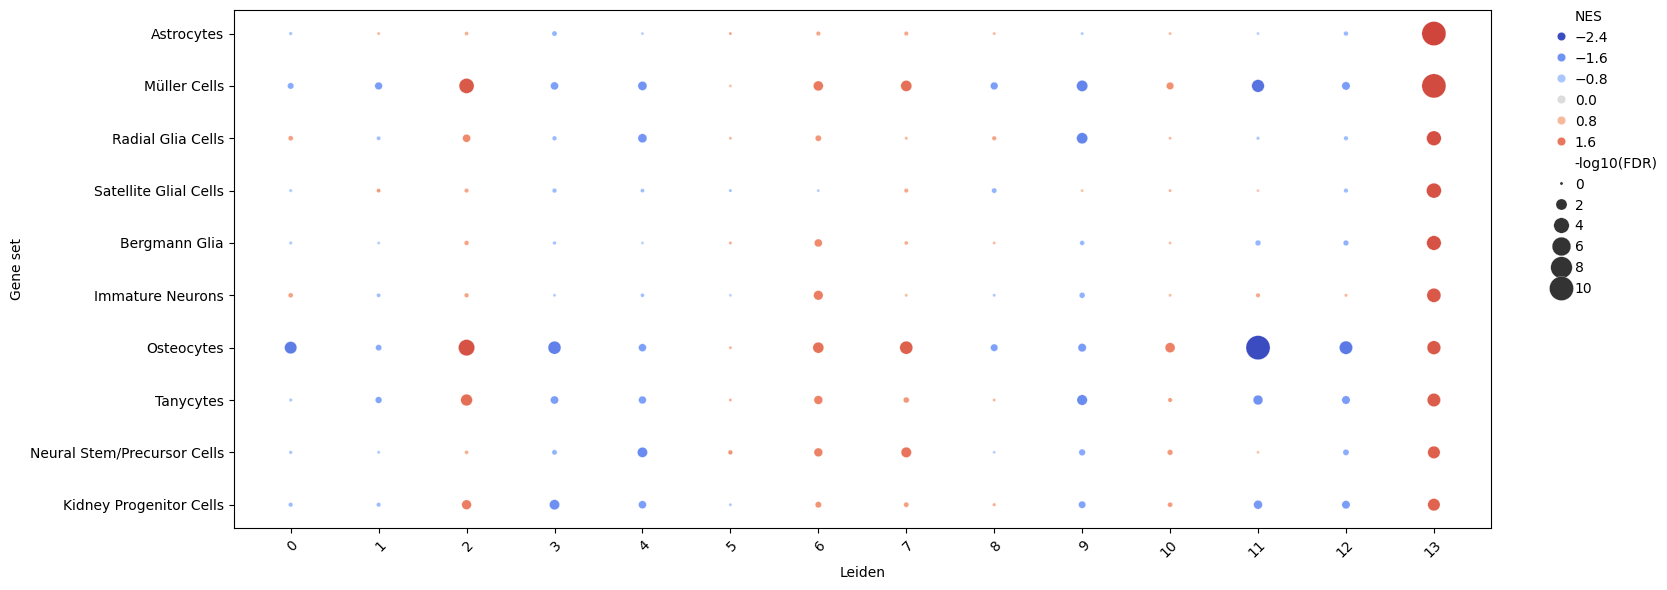

In [27]:
# Cell types in 13

single_cell_analysis.compare_gsea(adata, gene_set="PanglaoDB_Augmented_2021", group_key="leiden", top_from="13", significance_cutoff=0.5,
                                  n_top_terms=10)

13 consists of neurons

In [28]:
# Save diffusion map

adata.write_h5ad(
    "RNA Sequencing Data/diffusion_map_anndata.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)